# Notebook 4 — Bond-Network Entropy

## What we do here

We now compute the **Bond-Network Entropy (BNE)** of the silica glass. The idea:
1. Compute the H₁ barcode for *every* atom's local environment (LAE size = 30).
2. Group atoms by barcode — identical barcodes form an **equivalence class**.
3. Compute the empirical probability $p_m$ of each class.
4. Apply information entropy to the class distribution.

**Reference:** K. Iwanowski, G. Csányi, and M. Simoncelli,
*Phys. Rev. X* **15**, 041041 (2025)

---

## Theory: Shannon entropy and Bond-Network Entropy

**Shannon entropy** measures the diversity of a probability distribution. Given classes
with probabilities $p_1, p_2, \ldots, p_k$ (with $\sum_m p_m = 1$):

$$S = -\sum_m p_m \ln p_m$$

- If **one class dominates** ($p_1 \approx 1$): $S \approx 0$ — almost all atoms have the same environment,
  highly ordered.
- If **all classes are equally likely** ($p_m = 1/k$): $S = \ln k$ — maximum heterogeneity.

**BNE** applies this formula to the distribution of H₁ barcodes across all atoms.
A higher BNE means the bond network has greater topological diversity — more disorder.

The BNE depends on the LAE size $n$. We fix $n = 30$ here (a good compromise: large enough
to capture ring structure, small enough to compute quickly and avoid saturation effects). Notebook 6 explores how BNE
changes with $n$.

The **normalised growth rate** BNE$(n)/n$ is a material fingerprint that allows distinguishing different materials based on the level of disorder in their bond network.

## Library and visualization setup

In [1]:
import os, sys

import numpy as np
import pandas as pd
import scipy
from scipy.constants import physical_constants

import ase
from ase.io import read, write

matplotlib_style = 'fivethirtyeight'
import matplotlib.pyplot as plt
plt.style.use(matplotlib_style)
import seaborn as sns
sns.set_context('notebook')

class _Colors(object):
    """Helper class with different colors for plotting"""
    red = '#F15854'
    blue = '#5DA5DA'
    orange = '#FAA43A'
    green = '#60BD68'
    pink = '#F17CB0'
    brown = '#B2912F'
    purple = '#B276B2'
    yellow = '#DECF3F'
    gray = '#4D4D4D'
    cyan = '#00FFFF'
    rebecca_purple = '#663399'
    chartreuse = '#7FFF00'
    dark_red = '#8B0000'

    def __getitem__(self, i):
        color_list = [
            self.red,
            self.orange,
            self.green,
            self.blue,
            self.pink,
            self.brown,
            self.purple,
            self.yellow,
            self.gray,
            self.cyan,
            self.rebecca_purple,
            self.chartreuse,
            self.dark_red
        ]
        return color_list[i % len(color_list)]


Colors = _Colors()

from typing import Tuple, List
from tqdm import tqdm


In [2]:
# handy function to obtain distances to nearest atoms (distances) and their indices (idx_distances)

def obtain_distances_ase(
    atoms: ase.atoms.Atoms,
    n_smallest: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the n_smallest nearest-neighbour distances for every atom using
    the ASE Minimum Image Convention (preferred method).

    ASE's ``get_distances`` method handles the MIC correctly for all cell
    shapes (orthorhombic, monoclinic, triclinic), making it more accurate
    than the manual implementation for non-cubic cells.

    Parameters
    ----------
    atoms : ase.atoms.Atoms
        ASE Atoms object containing positions and cell (lattice vectors).
        Load from file with ``ase.io.read(filename)``.
    n_smallest : int
        Number of nearest neighbours (including central atom) to keep per atom.

    Returns
    -------
    distances : np.ndarray, shape (N, n_smallest)
        Sorted nearest-neighbour distances (in Ångström).
    idx_distances : np.ndarray, shape (N, n_smallest)
        Global atom indices corresponding to those distances.
    """

    distances = []
    idx_distances = []

    nat = len(atoms)
    atom_indices = np.arange(0, nat, 1)

    for k in tqdm(range(len(atoms)), desc="Distances"):

        # ASE computes MIC-corrected distances from atom k to all others
        distance = atoms.get_distances(k, atom_indices, mic=True)

        # keep only the n_smallest nearest neighbours using argpartition
        if n_smallest < nat:
            idx_distance = np.argpartition(distance, n_smallest)[:n_smallest]
        else:
            idx_distance = np.arange(0, nat, 1)

        # sort by distance within the selected neighbours
        idx_distance = idx_distance[np.argsort(distance[idx_distance])]

        idx_distances.append(idx_distance)
        distances.append(distance[idx_distance])

    distances = np.array(distances)
    idx_distances = np.array(idx_distances)
    return distances, idx_distances


In [3]:
from smooth_disorder.barcode import (
    obtain_local_number_environment_big_structures,
    obtain_H1_barcode,
    reduce_barcode,
    mu,
)

import networkx as nx

In [4]:
%%time
# read structure downloaded from https://www.pnas.org/doi/abs/10.1073/pnas.2422763122
filename = "./data/structural/silica_glass_5184_atoms/POSCAR"

atoms = read(filename)

atomic_numbers = atoms.get_atomic_numbers()

distances, idx_distances = obtain_distances_ase(atoms, 300)

Distances: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:13<00:00, 375.79it/s]

CPU times: user 11.5 s, sys: 4.53 s, total: 16.1 s
Wall time: 13.8 s


In [5]:
cutoff = 2.1 # for silica
adjacency_matrix = ((distances < cutoff) & (distances > 0.1)).astype(int)
coordination_number = adjacency_matrix.sum(axis=1)


## Calculate Bond-Network Entropy for the material

We define a helper function `calculate_barcode_distribution` that, given an LAE size,
loops over all atoms and returns the barcode equivalence classes and their counts.
This makes it easy to reuse for different $n$ values later.

> **Timing note:** The cell after this one loops over all 5184 atoms, computing one H₁
> barcode per atom. With LAE size 30 this takes approximately **15–60 seconds** on a laptop.
> The `%%time` command will show the exact duration.

In [6]:
def calculate_barcode_distribution(distances, idx_distances, adjacency_matrix, n_atoms, LAE_size):
    """
    Compute the H1 barcode for every atom's local environment and return
    the unique barcode classes with their counts.

    Parameters
    ----------
    distances : ndarray, shape (N, K)
        Sorted pairwise distances from obtain_distances_ase.
    idx_distances : ndarray, shape (N, K)
        Corresponding atom indices.
    adjacency_matrix : ndarray, shape (N, K)
        Compressed adjacency matrix (1 = bonded).
    n_atoms : int
        Total number of atoms.
    LAE_size : int
        Number of atoms in each local atomic environment.

    Returns
    -------
    Gs : dict
        Barcode arrays grouped by matrix shape.
    class_counts : ndarray
        Count of atoms in each barcode equivalence class.
    probabilities : ndarray
        Empirical probability of each class (sums to 1).
    entropy : float
        Shannon entropy of the class distribution (in nats).
    """
    shapes = {}
    Gs = {}

    for atom_index in tqdm(range(n_atoms), desc=f"LAE size {LAE_size}"):
        local_adj, layers, local_idx, global_idx = obtain_local_number_environment_big_structures(
            adjacency_matrix=adjacency_matrix,
            atom_index=atom_index,
            distances=distances,
            idx_distances=idx_distances,
            n_environment_atoms=LAE_size)

        G, F = obtain_H1_barcode(adjacency_matrix=local_adj, layers=layers, mu=mu)
        G = reduce_barcode(G)

        shape = G.shape
        if shape not in shapes:
            shapes[shape] = 1
            Gs[shape] = []
        Gs[shape].append(G)

    # Collect equivalence class counts across all shapes
    class_counts = []
    for shape, gs in Gs.items():
        _, counts = np.unique(gs, return_counts=True, axis=0)
        class_counts.extend(counts)

    class_counts = np.array(class_counts)
    probabilities = class_counts / class_counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()

    return Gs, class_counts, probabilities, entropy

In [7]:
%%time
LE_nat = 30
n_atoms = len(atoms)

Gs, class_counts, probabilities, entropy = calculate_barcode_distribution(
    distances, idx_distances, adjacency_matrix, n_atoms, LE_nat
)

LAE size 30: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:19<00:00, 270.41it/s]

CPU times: user 19.1 s, sys: 83 ms, total: 19.2 s
Wall time: 19.2 s


In [8]:
print(f"BNE (n={LE_nat}): {entropy:.4f} nats")
print(f"BNE / n = {entropy/LE_nat:.4f} nats per atom")

BNE (n=30): 4.1477 nats
BNE / n = 0.1383 nats per atom


${\rm BNE}(n)/n \approx 0.14$ **nats per atom.** What does this number mean?

For reference, different materials span a range of BNE growth rates:
- **Crystalline material** — all atoms identical → ${\rm BNE}(n)/n \approx 0$ (all barcodes the same)
- **Disordered carbon** — $\text{BNE}(n)/n$ varies between 0.05 (low-irradiated graphite), 0.1 (low-disordered nanoporous carbon), 0.15 (medium-disordered nanoporous carbon), 0.2 (heavily-disordered nanoporous carbon), 0.25 (amorphous carbon)

Silica glass has *very little coordination-number disorder* but a *non-zero bond-network disorder* —
BNE captures the latter, which simpler descriptors miss.

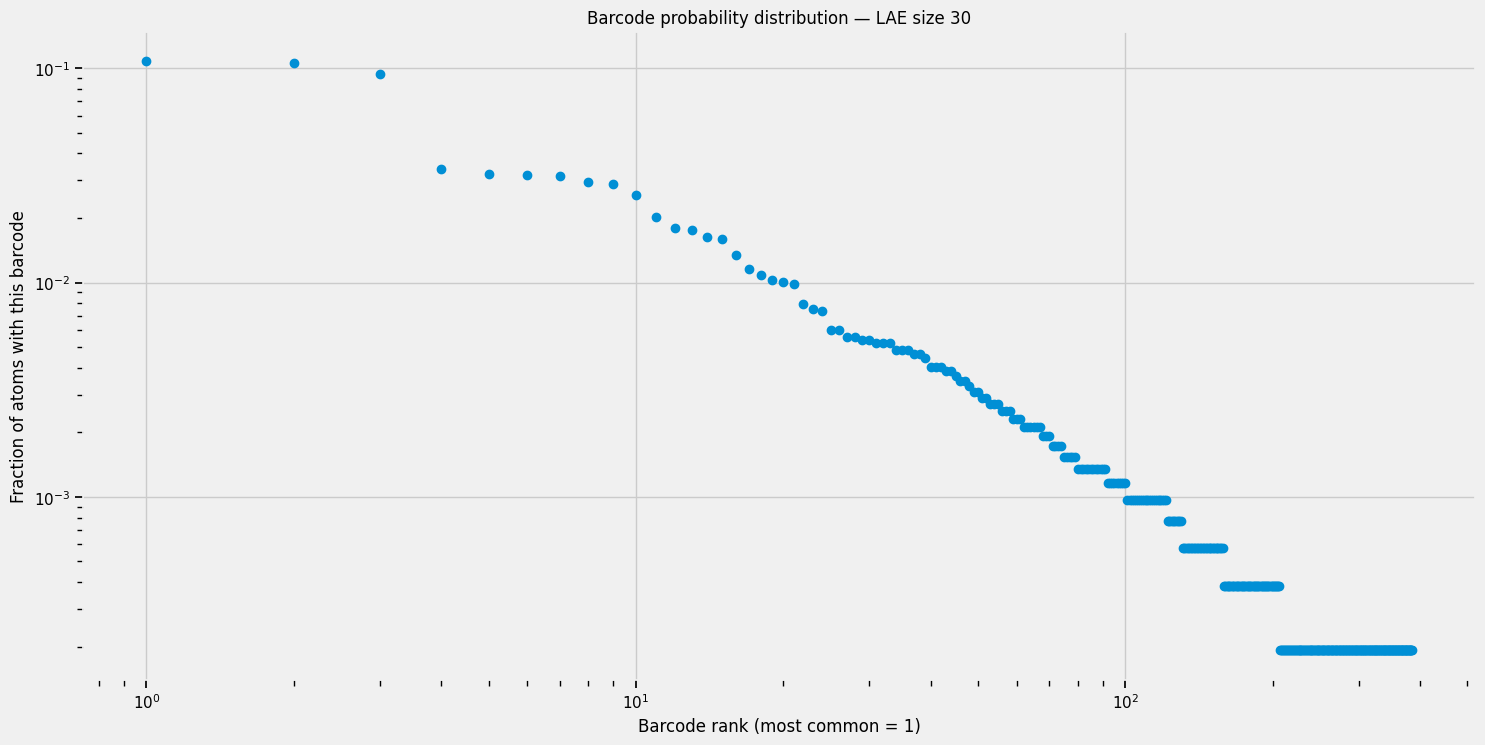

In [9]:
# Ranked distribution of barcode probabilities
# Each point is one equivalence class of barcodes; the x-axis ranks them by frequency

plt.figure(figsize=(16, 8))
plt.scatter(np.arange(1, len(probabilities)+1, 1), np.sort(probabilities)[::-1])
plt.xlabel("Barcode rank (most common = 1)")
plt.ylabel("Fraction of atoms with this barcode")
plt.title(f"Barcode probability distribution — LAE size {LE_nat}")

plt.xscale('log')
plt.yscale('log')

plt.show()

The 3 most common barcodes take about 30% of the distribution, let's find how they look like:

In [10]:
common_barcodes, common_barcode_counts = [], []

for shape, gs in Gs.items():
    equivalence_class, class_count = np.unique(gs, return_counts=True, axis=0)
    common_barcodes.append(equivalence_class[class_count > 0.06*n_atoms])
    common_barcode_counts.append(class_count[class_count > 0.06*n_atoms])

# Print the three most common barcodes and their counts
for barcode_group, count_group in zip(common_barcodes, common_barcode_counts):
    for b, c in zip(barcode_group, count_group):
        print(f"Count: {c}  ({100*c/n_atoms:.1f}%)")
        print(f"Barcode:\n{b}\n")

Count: 487  (9.4%)
Barcode:
[[0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

Count: 548  (10.6%)
Barcode:
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Count: 560  (10.8%)
Barcode:
[[0.]]



The three most common barcodes collectively account for ~30% of all atoms.

- `[[0.]]` (null barcode) — no rings in the 30-atom environment (the most common)
- Single bar at `[0,4]` — one ring closing at 4 hops from centre
- Single bar at `[0,5]` — one ring closing at 5 hops from centre

Let's visualise one representative atom for each of these three barcode types:

In [11]:
LE_nat = 30

for atom_index in range(0, n_atoms):
    local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(
        adjacency_matrix=adjacency_matrix,
        atom_index=atom_index,
        distances=distances,
        idx_distances=idx_distances,
        n_environment_atoms=LE_nat)

    G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                             layers=layers,
                             mu=mu)

    G = reduce_barcode(G)

    if np.array_equal(G, np.array([[0.]])):
        print(atom_index)
        break

25


0
[[0.]]


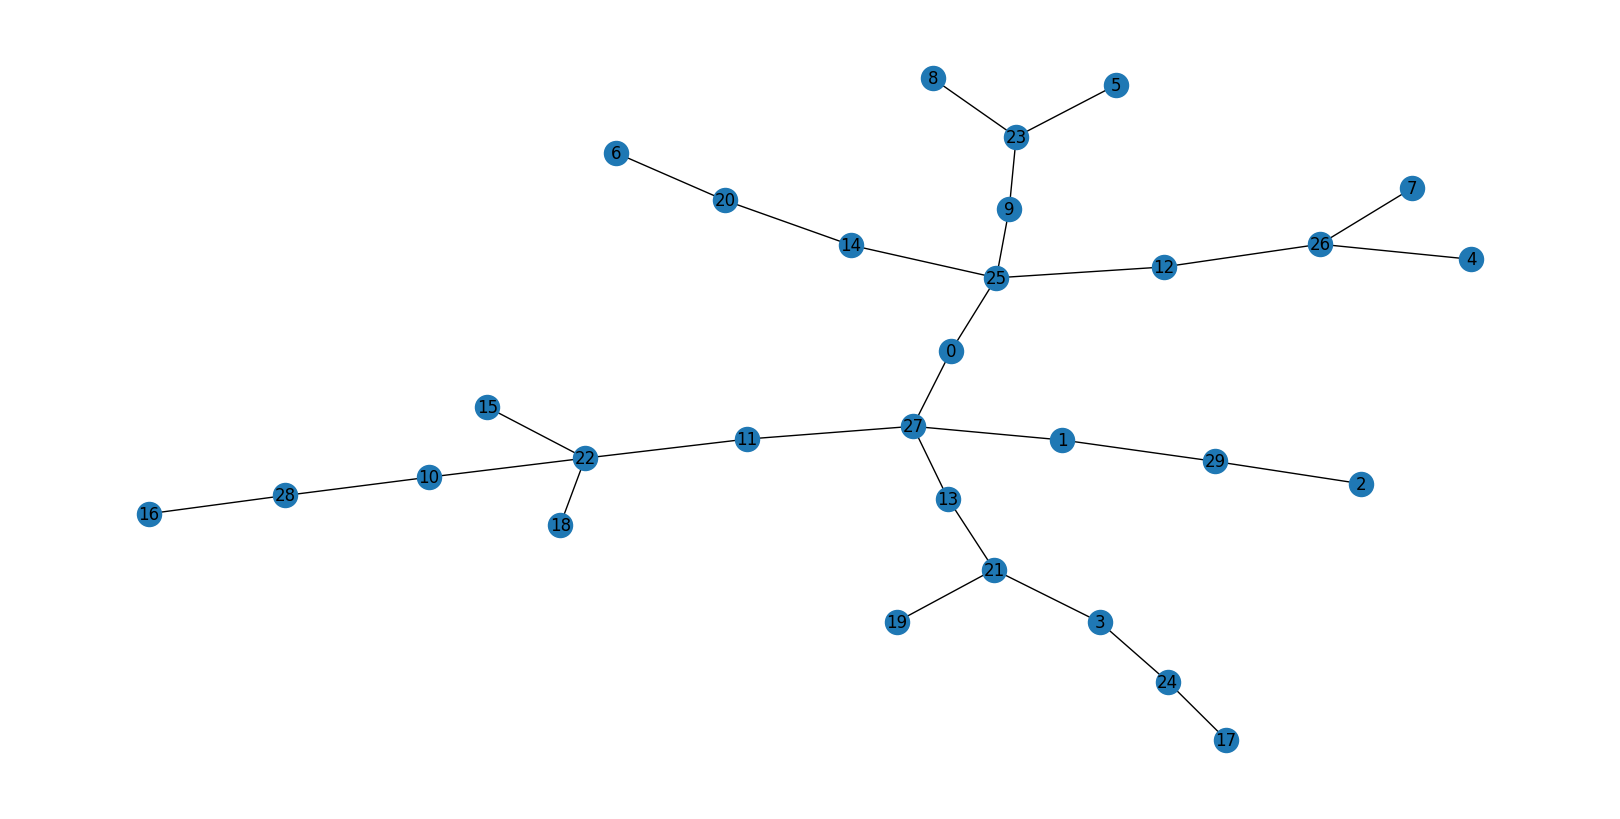

In [12]:
atom_index = 25
LAE_size = 30

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(adjacency_matrix,
                                                                                                               atom_index,
                                                                                                               distances,
                                                                                                               idx_distances,
                                                                                                               LAE_size)

print(local_atom_index)

G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                         layers=layers,
                         mu=mu)

G = reduce_barcode(G)
print(G)

graph = nx.from_numpy_array(local_adjacency_matrix)

plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.show()
# no rings

In [13]:
LE_nat = 30

for atom_index in range(0, n_atoms):
    local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(
        adjacency_matrix=adjacency_matrix,
        atom_index=atom_index,
        distances=distances,
        idx_distances=idx_distances,
        n_environment_atoms=LE_nat)

    G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                             layers=layers,
                             mu=mu)

    G = reduce_barcode(G)

    if np.array_equal(G, np.array([[0., 0., 0., 0., 1.],
                                   [0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0.]])):
        print(atom_index)
        break

7


0
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


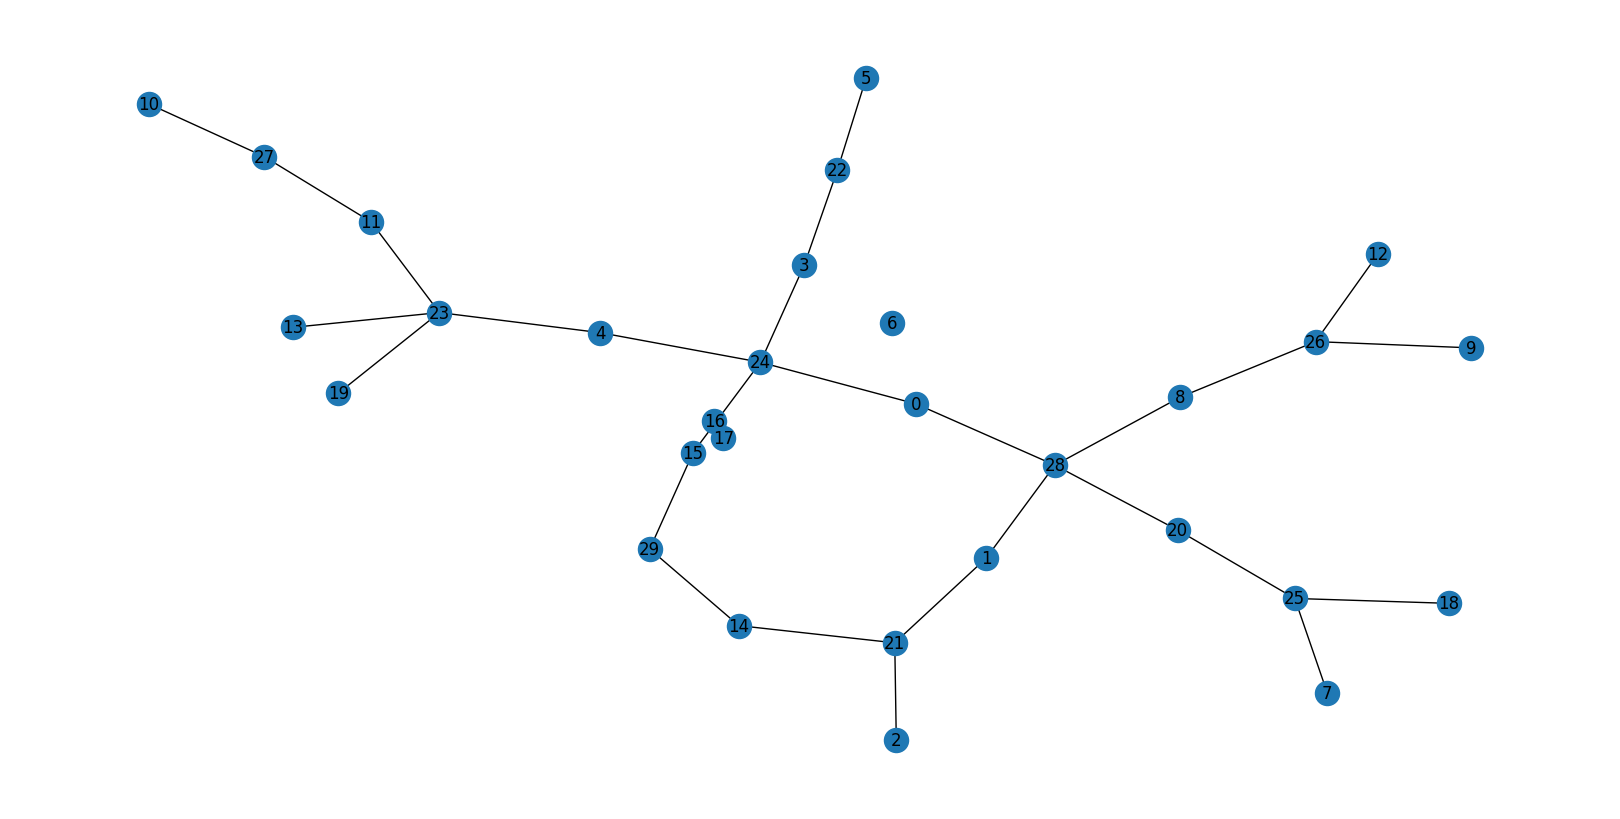

In [14]:
atom_index = 7
LAE_size = 30

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(adjacency_matrix,
                                                                                                               atom_index,
                                                                                                               distances,
                                                                                                               idx_distances,
                                                                                                               LAE_size)

print(local_atom_index)

G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                         layers=layers,
                         mu=mu)

G = reduce_barcode(G)
print(G)

graph = nx.from_numpy_array(local_adjacency_matrix)

plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.show()
# 1 [0, 4] ring

In [15]:
LE_nat = 30

for atom_index in range(0, n_atoms):
    local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(
        adjacency_matrix=adjacency_matrix,
        atom_index=atom_index,
        distances=distances,
        idx_distances=idx_distances,
        n_environment_atoms=LE_nat)

    G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                             layers=layers,
                             mu=mu)

    G = reduce_barcode(G)

    if np.array_equal(G, np.array([[0., 0., 0., 0., 0., 1.],
                                   [0., 0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0., 0.],
                                   [0., 0., 0., 0., 0., 0.]])):
        print(atom_index)
        break

0


0
[[0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


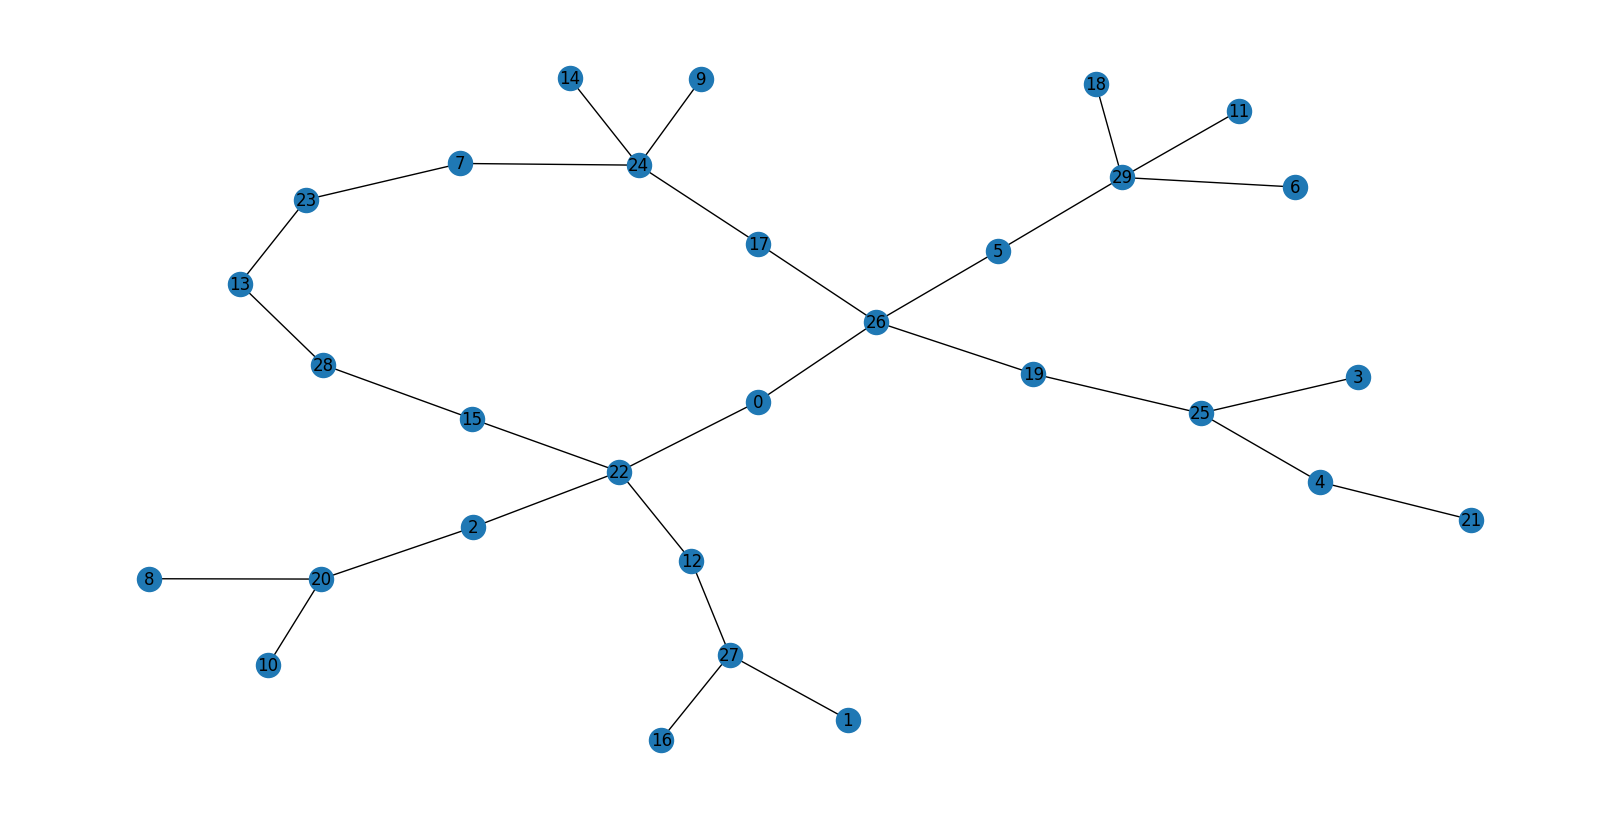

In [16]:
atom_index = 0
LAE_size = 30

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(adjacency_matrix,
                                                                                                               atom_index,
                                                                                                               distances,
                                                                                                               idx_distances,
                                                                                                               LAE_size)

print(local_atom_index)

G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                         layers=layers,
                         mu=mu)

G = reduce_barcode(G)
print(G)

graph = nx.from_numpy_array(local_adjacency_matrix)

plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.show()
# 1 [0, 5] ring

## BNE depends on the LAE size — a preview

Everything computed above uses LAE size $n = 30$. But BNE is not fixed: as we include more
distant atoms in each environment, we discover more rings, we are able to distinguish environments and the entropy grows.

The theoretical **maximum** BNE is $S_{\max} = \ln(N)$ — reached only if every one of the
$N = 5184$ atoms had a completely unique barcode. For silica, $\ln(5184) \approx 8.55$ nats.

In practice BNE grows roughly **linearly** with $n$ in an intermediate range, then saturates
as most atoms have distinct environments at very large $n$. The **growth rate** BNE$(n)/n$ in the
linear regime is the material fingerprint.

Notebook 5 (`5_BNE_workflow.py`) computes BNE for $n = 1, 2, \ldots, 80$ and saves the
results to HDF5 files (these are precomputed in this tutorial). Notebook 6 then plots the growth curve and extracts the growth rate.